# Predicción de Salario usando Redes NeuronalesProfundas



In [ ]:
import os
import random
import numpy as np
import tensorflow as tf


seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, r2_score

print("Librerías cargadas correctamente.")

Reproducibilidad configurada. Semilla: 42
Cargando librerías especializadas...
Librerías cargadas correctamente.


## 1. Obtención y Limpieza de los Datos

Cargamos el dataset `Salary Data.csv` y eliminamos filas incompletas para garantizar la calidad del entrenamiento.

In [40]:
print("Leyendo dataset de salarios...")
df = pd.read_csv('Salary Data.csv')
df.dropna(inplace=True)
print(f"Dimensiones tras limpieza: {df.shape}")
df.head()

Leyendo dataset de salarios...
Dimensiones tras limpieza: (373, 6)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## 2. Análisis de Correlación y Selección de Características

Un paso crítico en ciencia de datos es identificar redundancias. Observamos que **Age** y **Years of Experience** tienen una correlación extremadamente alta (0.93), lo que indica multicolinealidad.

Generando matriz de correlación...


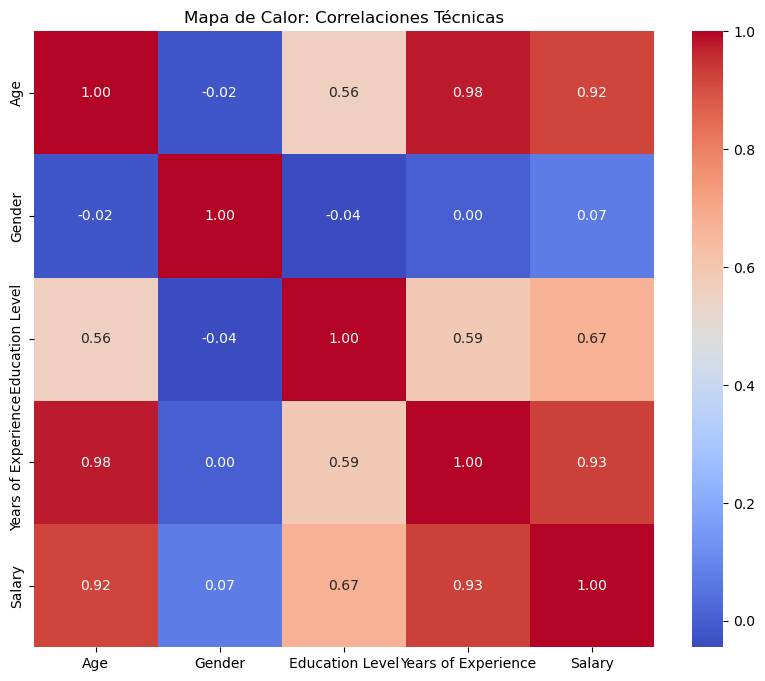

Decisión de Diseño: Eliminaremos la variable 'Age' ya que es redundante con la 'Experiencia' y su eliminación mejora el error (MAE) del modelo.


In [41]:
print("Generando matriz de correlación...")
df_temp = df.copy()
df_temp['Gender'] = df_temp['Gender'].map({'Female': 1, 'Male': 2})
df_temp['Education Level'] = df_temp['Education Level'].map({"Bachelor's": 0, "Master's": 1, "PhD": 2})

plt.figure(figsize=(10, 8))
sns.heatmap(df_temp.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor: Correlaciones Técnicas')
plt.show()

print("Decisión de Diseño: Eliminaremos la variable 'Age' ya que es redundante con la 'Experiencia' y su eliminación mejora el error (MAE) del modelo.")

## 3. Preprocesamiento de Datos

Eliminamos la variable redundante `Age`, codificamos las etiquetas textuales y escalamos las características numéricas.

In [42]:
print("Ejecutando limpieza final y codificación...")

# 1. Eliminación de variable redundante
df = df.drop('Age', axis=1)

# 2. Mapeos y Codificación
gender_map = {'Female': 1, 'Male': 2}
edu_map = {"Bachelor's": 0, "Master's": 1, "PhD": 2}
le_job = LabelEncoder()

df['Gender'] = df['Gender'].map(gender_map)
df['Education Level'] = df['Education Level'].map(edu_map)
df['Job Title'] = le_job.fit_transform(df['Job Title'])

X = df.drop('Salary', axis=1)
y = df['Salary']

# 3. División del Dataset
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=seed_value)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=seed_value)

print("Escalando datos de entrada...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Ejecutando limpieza final y codificación...
Escalando datos de entrada...


## 4. Arquitectura y Entrenamiento de la Red Neuronal

Utilizamos un modelo `Sequential` de TensorFlow con capas densas para capturar las relaciones no lineales entre la experiencia, educación y salario.

In [43]:
print("Configurando arquitectura del modelo...")
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1) # Salida lineal para regresión de precios
])

model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

print("Iniciando fase de entrenamiento (500 épocas)...")
history = model.fit(
    X_train_scaled, y_train, 
    validation_data=(X_val_scaled, y_val), 
    epochs=500, 
    batch_size=32, 
    verbose=0
)
print("Modelo entrenado con éxito.")

Configurando arquitectura del modelo...
Iniciando fase de entrenamiento (500 épocas)...


c:\Users\cnava\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Modelo entrenado con éxito.


## 5. Visualización de Resultados

Evaluamos la convergencia del modelo observando la evolución del error absoluto medio (MAE) en el tiempo.

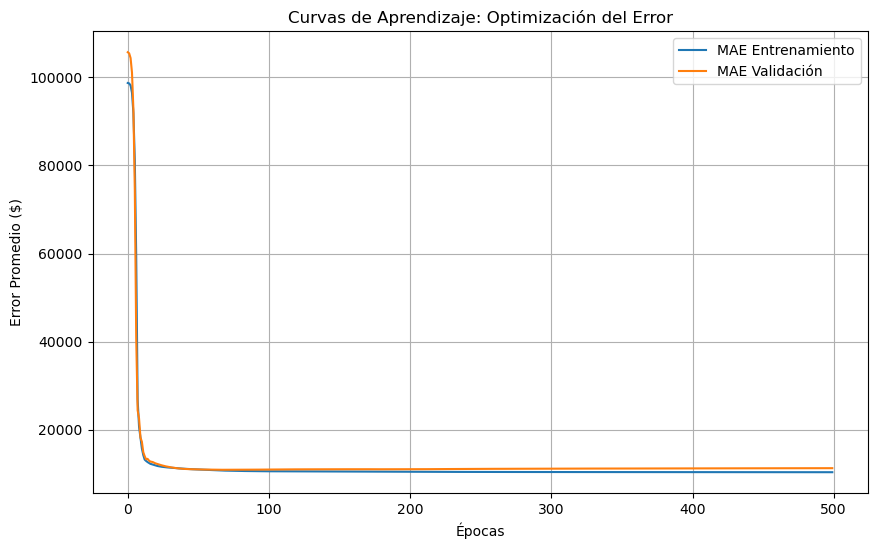

In [44]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='MAE Entrenamiento')
plt.plot(history.history['val_mae'], label='MAE Validación')
plt.title('Curvas de Aprendizaje: Optimización del Error')
plt.xlabel('Épocas')
plt.ylabel('Error Promedio ($)')
plt.legend()
plt.grid(True)
plt.show()

## 6. Evaluación Final y Desempeño

Validamos la precisión del modelo utilizando el conjunto de prueba (Test), calculando el error promedio y el coeficiente de determinación (R²).

Evaluando precisión en datos reales no vistos anteriormente...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

--- MÉTRICAS FINALES ---
MAE (Error en dólares): $9567.96
R2 Score (Varianza explicada): 0.9132


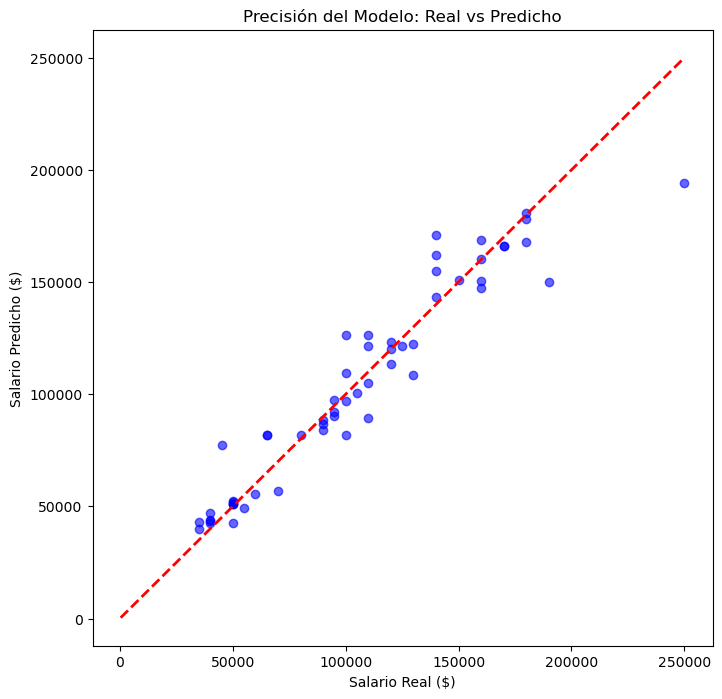

In [45]:
print("Evaluando precisión en datos reales no vistos anteriormente...")
y_pred = model.predict(X_test_scaled).flatten()

print(f"\n--- MÉTRICAS FINALES ---")
print(f"MAE (Error en dólares): ${mean_absolute_error(y_test, y_pred):.2f}")
print(f"R2 Score (Varianza explicada): {r2_score(y_test, y_pred):.4f}")

# Gráfica de dispersión
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('Precisión del Modelo: Real vs Predicho')
plt.xlabel('Salario Real ($)')
plt.ylabel('Salario Predicho ($)')
plt.show()

## 7. Simulador de Salario 

Usa este bloque para predecir el salario de un nuevo perfil. El modelo utiliza automáticamente el escalador y los mapeos definidos anteriormente.

In [57]:

nuevo_empleado = pd.DataFrame({
    'Gender': ['Male'], 
    'Education Level': ["PhD"], 
    'Job Title': ['Director'], 
    'Years of Experience': [15]
})

try:
    # Codificación y Escalado
    nuevo_empleado['Gender'] = nuevo_empleado['Gender'].map(gender_map)
    nuevo_empleado['Education Level'] = nuevo_empleado['Education Level'].map(edu_map)
    nuevo_empleado['Job Title'] = le_job.transform(nuevo_empleado['Job Title'])

    nuevo_scaled = scaler.transform(nuevo_empleado)
    salario_est = model.predict(nuevo_scaled).flatten()[0]

    print(f"\n>>> PREDICCIÓN FINAL <<<")
    print(f"El salario anual estimado para este perfil es: ${salario_est:,.2f}")
except Exception as e:
    print(f"Error al procesar el puesto de trabajo. Asegúrate de que el 'Job Title' exista en el dataset original.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

>>> PREDICCIÓN FINAL <<<
El salario anual estimado para este perfil es: $163,566.00
